In [15]:
import sqlite3
import pandas as pd
import seaborn as sns
import plotly.express as pl
import pingouin as pg
import numpy as np
sns.set(rc = {'figure.figsize':(12,6)}, style = "whitegrid")

In [16]:
#подключение к данным
connection = sqlite3.connect('C:/Users/spit/Desktop/weather_aus.sqlite')

In [17]:
#сохраняем все таблицы
WeatherData = pd.read_sql_query("""SELECT * FROM 'WeatherData'""", connection, index_col='weather_id')
RainfallData = pd.read_sql_query("""SELECT * FROM 'RainfallData'""", connection)
Locations = pd.read_sql_query("""SELECT * FROM 'Locations'""", connection)
WindData = pd.read_sql_query("""SELECT * FROM 'WindData'""", connection)

In [18]:
print('WeatherData. кол-во строк:',WeatherData.shape[0], 'кол-во столбцов:',WeatherData.shape[1])
print('RainfallData. кол-во строк:',RainfallData.shape[0], 'кол-во столбцов:',RainfallData.shape[1])
print('Locations. кол-во строк:',Locations.shape[0], 'кол-во столбцов:',Locations.shape[1])
print('WindData. кол-во строк:',WindData.shape[0], 'кол-во столбцов:',WindData.shape[1])

WeatherData. кол-во строк: 145460 кол-во столбцов: 15
RainfallData. кол-во строк: 145460 кол-во столбцов: 4
Locations. кол-во строк: 49 кол-во столбцов: 2
WindData. кол-во строк: 145460 кол-во столбцов: 8


#### Рассмотрим WeatherData

In [19]:
# сколько строк и столбцов в df
WeatherData.shape

(145460, 15)

In [20]:
WeatherData.head()

,date,location_id,min_temp,max_temp,sunshine,humidity_9am,humidity_3pm,pressure_9am,pressure_3pm,cloud_9am,cloud_3pm,temp_9am,temp_3pm,rain_today,rain_tomorrow
weather_id,,,,,,,,,,,,,,,
1,2008-12-01,1,13.4,22.9,NaN,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
2,2008-12-02,1,7.4,25.1,NaN,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
3,2008-12-03,1,12.9,25.7,NaN,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
4,2008-12-04,1,9.2,28.0,NaN,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
5,2008-12-05,1,17.5,32.3,NaN,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [21]:
WeatherData.to_excel('WeatherData.xlsx', index=False)

In [14]:
WeatherData['date'].nunique()

3436

In [74]:
# сколько строк в DataFrame содержат только NaN значения
WeatherData.isna().all(axis=1).sum()

0

In [8]:
# сколько дубликатов в DF
WeatherData.duplicated().sum()

0

In [9]:
# сколько Nan в каждом столбце
WeatherData.isna().sum()

date                 0
location_id          0
min_temp          1485
max_temp          1261
sunshine         69835
humidity_9am      2654
humidity_3pm      4507
pressure_9am     15065
pressure_3pm     15028
cloud_9am        55888
cloud_3pm        59358
temp_9am          1767
temp_3pm          3609
rain_today        3261
rain_tomorrow     3267
dtype: int64

В процессе анализа данных мы выявили значительное количество пропусков. В связи с этим было принято решение об их обработке следующим образом:

- Столбец sunshine: около 50% данных в этом столбце содержат значения NaN. Эти пропуски могут указывать на отсутствие солнечного света в течение дня или быть результатом ошибки в системе. В связи с этим, пропуски в этом столбце будут интерпретированы как отсутствие солнечного света и заменены на нулевые значения

- Пропуски в количественных переменных: для количественных переменных, таких как температура или количество осадков, пропуски будут заменены на медианные значения соответствующих столбцов. Медиана является более устойчивой к выбросам по сравнению со средним значением, что позволяет эффективно заполнять пропуски без искажения данных.

- Удаление строк с пропусками в столбцах (качественные переменные) rain_today и rain_tomorrow: для этих столбцов пропусков очень мало, и они не оказывают существенного влияния на анализ. Поэтому строки с пропусками в этих столбцах будут удалены.

In [10]:
# заменем все пропуски в столбце sunshine на 0.
WeatherData['sunshine'].fillna(0, inplace=True)

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\1191828411.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  WeatherData['sunshine'].fillna(0, inplace=True)


Заменим пропуски у количественных переменных на медиану в каждом из указанных столбцов.\
Например мы берем стобец min_temp, вычислеям медиану по этому столбцу и заменяем пропуски этой мидианой

In [11]:
columns_to_replace = ['min_temp', 'max_temp', 'humidity_9am', 'humidity_3pm', 
                      'pressure_9am', 'pressure_3pm', 'cloud_9am', 'cloud_3pm', 
                      'temp_9am', 'temp_3pm']

In [12]:
for colum in columns_to_replace:
    WeatherData[colum] = WeatherData[colum].fillna(WeatherData[colum].median())

In [13]:
WeatherData.isna().sum()

date                0
location_id         0
min_temp            0
max_temp            0
sunshine            0
humidity_9am        0
humidity_3pm        0
pressure_9am        0
pressure_3pm        0
cloud_9am           0
cloud_3pm           0
temp_9am            0
temp_3pm            0
rain_today       3261
rain_tomorrow    3267
dtype: int64

Остались только качественные переменные. 
Удалим эти пропуски(строки). Это всего лишь 2.24 % данных

In [14]:
3267 /145460 * 100

2.245978275814657

In [15]:
# Удалить оставшиеся пропуски
WeatherData = WeatherData.dropna()

In [16]:
WeatherData.isna().sum()

date             0
location_id      0
min_temp         0
max_temp         0
sunshine         0
humidity_9am     0
humidity_3pm     0
pressure_9am     0
pressure_3pm     0
cloud_9am        0
cloud_3pm        0
temp_9am         0
temp_3pm         0
rain_today       0
rain_tomorrow    0
dtype: int64

In [17]:
WeatherData.shape

(140787, 15)

#### рассмотрим теперь RainfallData 

In [18]:
RainfallData.head()

,rainfall_id,weather_id,rainfall,evaporation
0,1,1,0.6,NaN
1,2,2,0.0,NaN
2,3,3,0.0,NaN
3,4,4,0.0,NaN
4,5,5,1.0,NaN


In [19]:
RainfallData.shape

(145460, 4)

In [20]:
# сколько строк в DataFrame содержат только NaN значения
RainfallData.isna().all(axis=1).sum()

0

In [21]:
# сколько дубликатов в DF
RainfallData.duplicated().sum()

0

In [22]:
RainfallData.isna().sum()

rainfall_id        0
weather_id         0
rainfall        3261
evaporation    62790
dtype: int64

evaporation - все nan в этом стобце  обозначают, что испарения не было \
rainfall - ошибка системы ее надо удалить тк именно 3261 количество nan было в таблице WeatherData rain_today_NAN = 3261.Считаем это ошибкой системы

In [23]:
# замена всеех пропусков в evaporation на 0
RainfallData.evaporation.fillna(0, inplace=True)

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\1108408377.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  RainfallData.evaporation.fillna(0, inplace=True)


In [24]:
# удаляем оставшиеся пропуски в столбце rainfall
RainfallData = RainfallData.dropna()

In [25]:
RainfallData.isna().sum()

rainfall_id    0
weather_id     0
rainfall       0
evaporation    0
dtype: int64

In [26]:
RainfallData.shape

(142199, 4)

#### рассмотрим теперь Locations

In [27]:
Locations.shape

(49, 2)

In [28]:
Locations.head()

,location_id,location_name
0,1,Albury
1,2,BadgerysCreek
2,3,Cobar
3,4,CoffsHarbour
4,5,Moree


In [29]:
Locations.isna().all(axis=1).sum()

0

In [30]:
Locations.duplicated().sum()

0

In [31]:
Locations.isna().sum()

location_id      0
location_name    0
dtype: int64

#### рассмотрим теперь WindData

In [32]:
WindData.head()

,wind_id,weather_id,wind_gust_dir,wind_gust_speed,wind_dir_9am,wind_dir_3pm,wind_speed_9am,wind_speed_3pm
0,1,1,W,44.0,W,WNW,20.0,24.0
1,2,2,WNW,44.0,NNW,WSW,4.0,22.0
2,3,3,WSW,46.0,W,WSW,19.0,26.0
3,4,4,NE,24.0,SE,E,11.0,9.0
4,5,5,W,41.0,ENE,NW,7.0,20.0


In [33]:
WeatherData.shape

(140787, 15)

In [34]:
WeatherData.duplicated().sum()

0

In [35]:
WeatherData.isna().all(axis=1).sum()

0

In [36]:
WindData.wind_dir_9am.unique()

array(['W', 'NNW', 'SE', 'ENE', 'SW', 'SSE', 'S', 'NE', None, 'SSW', 'N',
       'WSW', 'ESE', 'E', 'NW', 'WNW', 'NNE'], dtype=object)

In [37]:
WindData.isna().sum()

wind_id                0
weather_id             0
wind_gust_dir      10326
wind_gust_speed    10263
wind_dir_9am       10566
wind_dir_3pm        4228
wind_speed_9am      1767
wind_speed_3pm      3062
dtype: int64

Принимаем решение по удалению этих пропусков по нескольким причинам: 
1) Малое количество пропусков
2) Невозможность надежной замены: 
    замена пропусков в столбцах с качественными данными, такими как wind_gust_dir (например, направления ветра), может быть
    затруднена

In [38]:
WindData = WindData.dropna()

In [39]:
WindData.shape

(126840, 8)

Объеденям все таблицы в 1 dataframe, это поможет нам согласовать все таблицы между собой и преобразование данных в единую структуру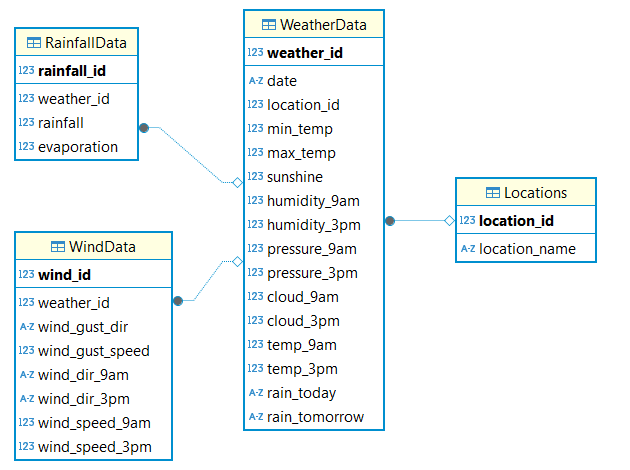

In [40]:
df_combined = WeatherData.merge(RainfallData, on='weather_id') \
                    .merge(WindData, on='weather_id') \
                    .merge(Locations, on ='location_id')

In [41]:
df_combined.isna().sum()

weather_id         0
date               0
location_id        0
min_temp           0
max_temp           0
sunshine           0
humidity_9am       0
humidity_3pm       0
pressure_9am       0
pressure_3pm       0
cloud_9am          0
cloud_3pm          0
temp_9am           0
temp_3pm           0
rain_today         0
rain_tomorrow      0
rainfall_id        0
rainfall           0
evaporation        0
wind_id            0
wind_gust_dir      0
wind_gust_speed    0
wind_dir_9am       0
wind_dir_3pm       0
wind_speed_9am     0
wind_speed_3pm     0
location_name      0
dtype: int64

In [42]:
df_combined.dtypes

weather_id           int64
date                object
location_id          int64
min_temp           float64
max_temp           float64
sunshine           float64
humidity_9am       float64
humidity_3pm       float64
pressure_9am       float64
pressure_3pm       float64
cloud_9am          float64
cloud_3pm          float64
temp_9am           float64
temp_3pm           float64
rain_today          object
rain_tomorrow       object
rainfall_id          int64
rainfall           float64
evaporation        float64
wind_id              int64
wind_gust_dir       object
wind_gust_speed    float64
wind_dir_9am        object
wind_dir_3pm        object
wind_speed_9am     float64
wind_speed_3pm     float64
location_name       object
dtype: object

In [43]:
df_combined.shape

(123710, 27)

In [44]:
df_combined.shape[0] / 145460 * 100

85.04743572116045

In [45]:
# Сохранение DataFrame в Excel
# df_combined.to_excel('combined_data.xlsx', index=False)

#### Проверим наше решение по замене пропусков sunshine на 0, которое обозначает, что солнца не было в этот день

<Axes: xlabel='sunshine', ylabel='Count'>

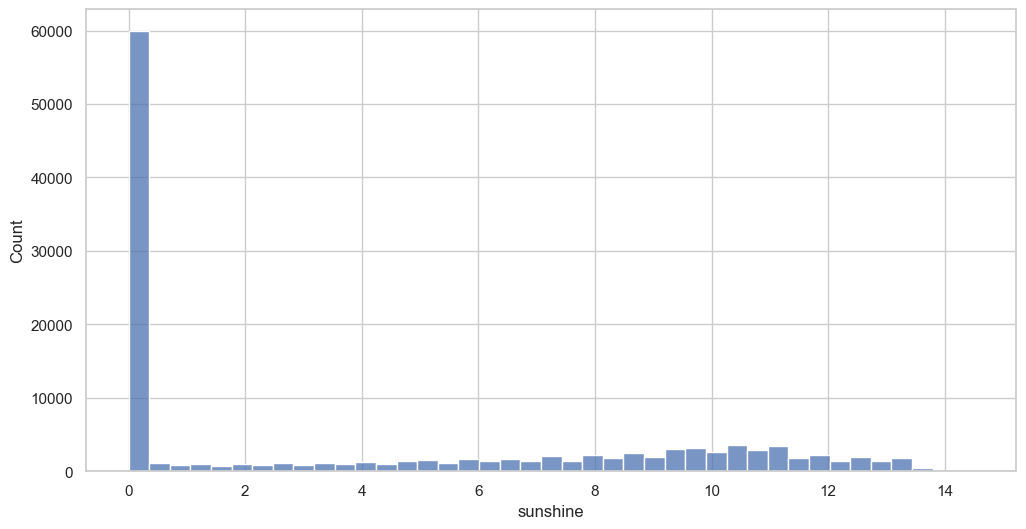

In [46]:
sns.histplot(df_combined.sunshine)           

In [47]:
df_combined.sunshine.value_counts(normalize=True).mul(100)

sunshine
0.0     47.390672
11.0     0.804300
10.8     0.801875
10.7     0.798642
10.5     0.765500
          ...    
14.0     0.010508
14.1     0.004850
14.3     0.003233
14.2     0.001617
14.5     0.000808
Name: proportion, Length: 145, dtype: float64

в 47% дней нет солнце. Это вполне может быть. В некоторых регионах Австралии, где часто бывают пасмурные или дождливые дни, особенно в зимние месяцы. В таких местах, как юго-восточное побережье (например, Мельбурн), зима может сопровождаться значительным количеством дождей и облачности.

В среднем, на всей территории Австралии солнечные дни могут составлять от 60% до 80% в год, но в некоторых регионах и в определённые сезоны процент пасмурных или дождливых дней может быть выше.

Ответим на след. вопросы:\
1.	Как распределяются минимальная и максимальная температура по местоположениям?

2.	Какие местоположения имеют наибольшее количество дней с осадками?

3.	Как влажность и давление влияют на вероятность осадков?

4.	Как направление и скорость ветра коррелируют с осадками?

5.	Какие местоположения имеют наибольшую разницу в давлении между утром и днем?

6.	Как облачность влияет на температуру и осадки?


#### 1. Как распределяются минимальная и максимальная температура по местоположениям?
Для ответа на этот вопрос нужно проанализировать, как значения минимальной и максимальной температуры варьируются в зависимости от местоположения. Для каждой локации берем среднее значение столбцов min_temp и max_temp , а также визуализируем данные

In [48]:
temp_locations = df_combined.groupby('location_name')[['min_temp', 'max_temp']].mean().reset_index()
temp_locations

,location_name,min_temp,max_temp
0,Adelaide,12.854479,23.074363
1,Albury,10.375133,23.401309
2,AliceSprings,13.692613,29.590902
3,BadgerysCreek,11.458544,24.101953
4,Ballarat,7.465665,18.335820
5,Bendigo,9.016294,22.044661
6,Brisbane,16.405447,26.462793
7,Cairns,21.191448,29.533103
8,Canberra,7.159124,21.013505
9,Cobar,13.122667,25.842667


#### 2.	Какие местоположения имеют наибольшее количество дней с осадками?

In [75]:
df_combined

,weather_id,date,location_id,min_temp,max_temp,sunshine,humidity_9am,humidity_3pm,pressure_9am,pressure_3pm,...,evaporation,wind_id,wind_gust_dir,wind_gust_speed,wind_dir_9am,wind_dir_3pm,wind_speed_9am,wind_speed_3pm,location_name,dif_pres
0,1,2008-12-01,1,13.4,22.9,0.0,71.0,22.0,1007.7,1007.1,...,0.0,1,W,44.0,W,WNW,20.0,24.0,Albury,0.6
1,2,2008-12-02,1,7.4,25.1,0.0,44.0,25.0,1010.6,1007.8,...,0.0,2,WNW,44.0,NNW,WSW,4.0,22.0,Albury,2.8
2,3,2008-12-03,1,12.9,25.7,0.0,38.0,30.0,1007.6,1008.7,...,0.0,3,WSW,46.0,W,WSW,19.0,26.0,Albury,-1.1
3,4,2008-12-04,1,9.2,28.0,0.0,45.0,16.0,1017.6,1012.8,...,0.0,4,NE,24.0,SE,E,11.0,9.0,Albury,4.8
4,5,2008-12-05,1,17.5,32.3,0.0,82.0,33.0,1010.8,1006.0,...,0.0,5,W,41.0,ENE,NW,7.0,20.0,Albury,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123705,145455,2017-06-20,49,3.5,21.8,0.0,59.0,27.0,1024.7,1021.2,...,0.0,145455,E,31.0,ESE,E,15.0,13.0,Uluru,3.5
123706,145456,2017-06-21,49,2.8,23.4,0.0,51.0,24.0,1024.6,1020.3,...,0.0,145456,E,31.0,SE,ENE,13.0,11.0,Uluru,4.3
123707,145457,2017-06-22,49,3.6,25.3,0.0,56.0,21.0,1023.5,1019.1,...,0.0,145457,NNW,22.0,SE,N,13.0,9.0,Uluru,4.4
123708,145458,2017-06-23,49,5.4,26.9,0.0,53.0,24.0,1021.0,1016.8,...,0.0,145458,N,37.0,SE,WNW,9.0,9.0,Uluru,4.2


In [87]:
size_rain = df_combined.query('rain_today == "Yes"').groupby('location_name', as_index=False).size().sort_values(by='size',ascending=False)
size_rain.head()

,location_name,size
31,Portland,1061
7,Cairns,915
21,MountGambier,890
25,NorfolkIsland,890
41,Walpole,834


In [80]:
pl.bar(size_rain, x='location_name', y = 'size', title="number of days with precipitation by Location")

#### 3. Как влажность и давление влияют на вероятность осадков?

In [52]:
df_rain_pressure_humidity = df_combined[["humidity_9am", "humidity_3pm", "pressure_9am",
                                         "pressure_3pm", "rain_tomorrow"]]

In [53]:
df_rain_pressure_humidity["rain_tomorrow"] = df_rain_pressure_humidity["rain_tomorrow"] \
                                            .map({"Yes": 1, "No": 0})

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\1493201713.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [54]:
df_rain_pressure_humidity_corr = df_rain_pressure_humidity.corr()
df_rain_pressure_humidity_corr

,humidity_9am,humidity_3pm,pressure_9am,pressure_3pm,rain_tomorrow
humidity_9am,1.000000,0.678832,0.108734,0.159187,0.273159
humidity_3pm,0.678832,1.000000,-0.034117,0.043260,0.451771
pressure_9am,0.108734,-0.034117,1.000000,0.959543,-0.235364
pressure_3pm,0.159187,0.043260,0.959543,1.000000,-0.215596
rain_tomorrow,0.273159,0.451771,-0.235364,-0.215596,1.000000


In [55]:
#df_rain_pressure_humidity_corr.to_excel('df_rain_pressure_humidity_corr.xlsx', index=False)

<Axes: >

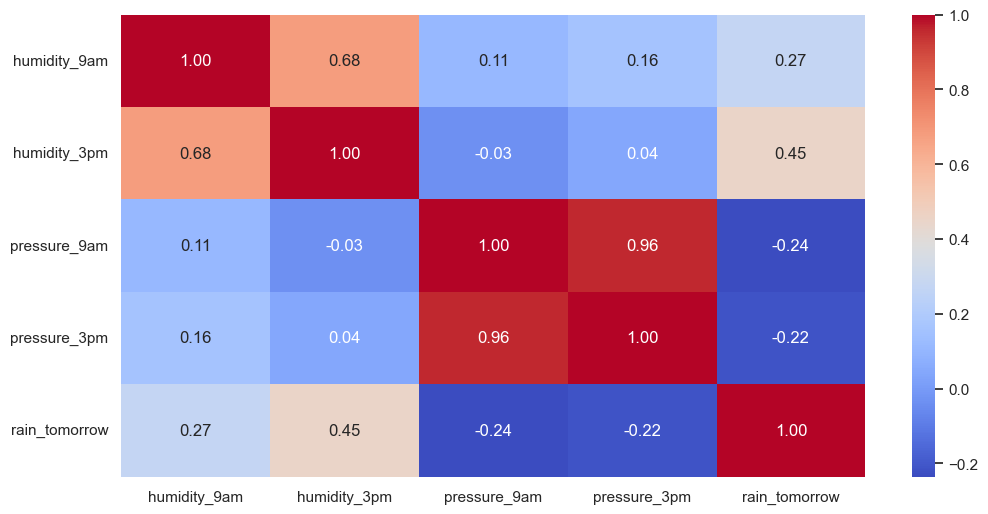

In [56]:
sns.heatmap(df_rain_pressure_humidity.corr(), annot=True, cmap='coolwarm', fmt='.2f', cbar=True)

#### 4.	Как направление и скорость ветра коррелируют с осадками?

In [57]:
wind_dir_rain = df_combined[['wind_dir_9am','wind_dir_3pm', 'wind_speed_9am', 
                             'wind_speed_3pm', 'rain_today','rain_tomorrow']]
wind_dir_rain.head()

,wind_dir_9am,wind_dir_3pm,wind_speed_9am,wind_speed_3pm,rain_today,rain_tomorrow
0,W,WNW,20.0,24.0,No,No
1,NNW,WSW,4.0,22.0,No,No
2,W,WSW,19.0,26.0,No,No
3,SE,E,11.0,9.0,No,No
4,ENE,NW,7.0,20.0,No,No


In [58]:
wind_dir_rain["rain_tomorrow"] = wind_dir_rain["rain_tomorrow"].map({"Yes": 1, "No": 0})
wind_dir_rain["rain_today"] = wind_dir_rain["rain_today"].map({"Yes": 1, "No": 0})

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\1057221853.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\1057221853.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [59]:
wind_dir_rain['wind_dir_9am'] = wind_dir_rain['wind_dir_9am'].map({ 'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
                                                                    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
                                                                    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
                                                                    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5})

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\4106008223.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [60]:
wind_dir_rain['wind_dir_3pm'] = wind_dir_rain['wind_dir_3pm'].map({ 'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
                                                                    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
                                                                    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
                                                                    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5})

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\3211491561.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [61]:
wind_dir_rain_corr = wind_dir_rain.corr()
wind_dir_rain_corr

,wind_dir_9am,wind_dir_3pm,wind_speed_9am,wind_speed_3pm,rain_today,rain_tomorrow
wind_dir_9am,1.000000,0.256541,-0.004989,0.068032,0.150275,0.035053
wind_dir_3pm,0.256541,1.000000,0.015008,0.074251,0.102617,0.046580
wind_speed_9am,-0.004989,0.015008,1.000000,0.504546,0.099070,0.093531
wind_speed_3pm,0.068032,0.074251,0.504546,1.000000,0.085049,0.096030
rain_today,0.150275,0.102617,0.099070,0.085049,1.000000,0.315867
rain_tomorrow,0.035053,0.046580,0.093531,0.096030,0.315867,1.000000


In [62]:
# wind_dir_rain_corr.to_excel('wind_dir_rain_corr.xlsx', index=False)

<Axes: >

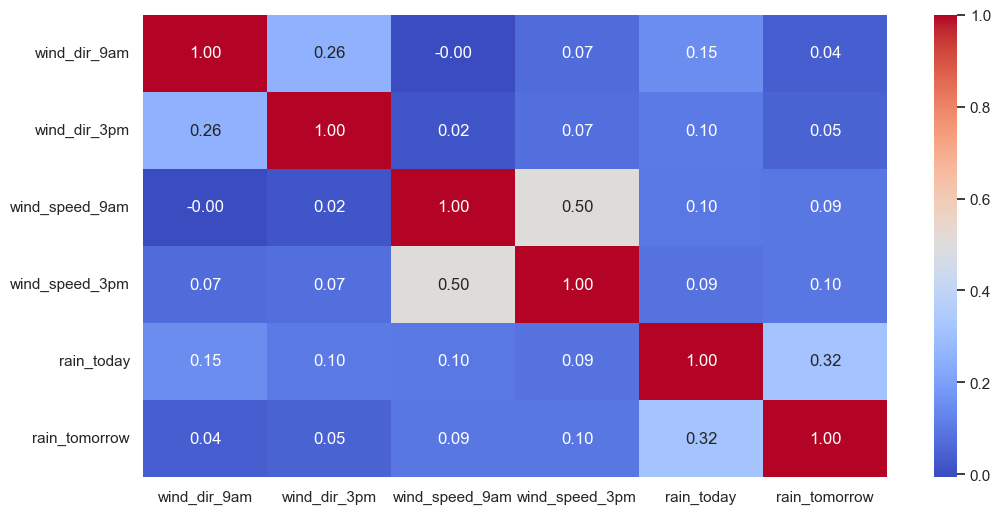

In [63]:
sns.heatmap(wind_dir_rain.corr(), annot=True, cmap='coolwarm', fmt='.2f', cbar=True)

#### 5.	Какие местоположения имеют наибольшую разницу в давлении между утром и днем?

In [88]:
df_combined

,weather_id,date,location_id,min_temp,max_temp,sunshine,humidity_9am,humidity_3pm,pressure_9am,pressure_3pm,...,evaporation,wind_id,wind_gust_dir,wind_gust_speed,wind_dir_9am,wind_dir_3pm,wind_speed_9am,wind_speed_3pm,location_name,dif_pres
0,1,2008-12-01,1,13.4,22.9,0.0,71.0,22.0,1007.7,1007.1,...,0.0,1,W,44.0,W,WNW,20.0,24.0,Albury,0.6
1,2,2008-12-02,1,7.4,25.1,0.0,44.0,25.0,1010.6,1007.8,...,0.0,2,WNW,44.0,NNW,WSW,4.0,22.0,Albury,2.8
2,3,2008-12-03,1,12.9,25.7,0.0,38.0,30.0,1007.6,1008.7,...,0.0,3,WSW,46.0,W,WSW,19.0,26.0,Albury,-1.1
3,4,2008-12-04,1,9.2,28.0,0.0,45.0,16.0,1017.6,1012.8,...,0.0,4,NE,24.0,SE,E,11.0,9.0,Albury,4.8
4,5,2008-12-05,1,17.5,32.3,0.0,82.0,33.0,1010.8,1006.0,...,0.0,5,W,41.0,ENE,NW,7.0,20.0,Albury,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123705,145455,2017-06-20,49,3.5,21.8,0.0,59.0,27.0,1024.7,1021.2,...,0.0,145455,E,31.0,ESE,E,15.0,13.0,Uluru,3.5
123706,145456,2017-06-21,49,2.8,23.4,0.0,51.0,24.0,1024.6,1020.3,...,0.0,145456,E,31.0,SE,ENE,13.0,11.0,Uluru,4.3
123707,145457,2017-06-22,49,3.6,25.3,0.0,56.0,21.0,1023.5,1019.1,...,0.0,145457,NNW,22.0,SE,N,13.0,9.0,Uluru,4.4
123708,145458,2017-06-23,49,5.4,26.9,0.0,53.0,24.0,1021.0,1016.8,...,0.0,145458,N,37.0,SE,WNW,9.0,9.0,Uluru,4.2


In [64]:
df_combined['dif_pres'] = df_combined.pressure_9am - df_combined.pressure_3pm

In [65]:
dif_pres = df_combined.groupby('location_name', as_index=False)['dif_pres'].mean() \
                        .sort_values(by = 'dif_pres',ascending = False)
dif_pres.head(10)

,location_name,dif_pres
15,Katherine,4.302851
39,Uluru,3.819986
2,AliceSprings,3.815066
12,Darwin,3.552837
20,Moree,3.387704
37,Townsville,3.254785
6,Brisbane,3.113668
7,Cairns,3.048103
32,Richmond,2.884853
13,GoldCoast,2.701448


In [66]:
pl.bar(dif_pres, x = 'location_name', y='dif_pres')

#### 6.	Как облачность влияет на температуру и осадки?

In [67]:
temp_clound = df_combined[['cloud_9am', 'cloud_3pm', 'temp_9am', 'temp_3pm','rain_today', 'rain_tomorrow']]

In [68]:
temp_clound["rain_today"] = temp_clound["rain_today"].map({"Yes": 1, "No": 0})
temp_clound["rain_tomorrow"] = temp_clound["rain_tomorrow"].map({"Yes": 1, "No": 0})

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\2264526045.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\spit\AppData\Local\Temp\ipykernel_25208\2264526045.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [69]:
temp_clound.head()

,cloud_9am,cloud_3pm,temp_9am,temp_3pm,rain_today,rain_tomorrow
0,8.0,5.0,16.9,21.8,0,0
1,5.0,5.0,17.2,24.3,0,0
2,5.0,2.0,21.0,23.2,0,0
3,5.0,5.0,18.1,26.5,0,0
4,7.0,8.0,17.8,29.7,0,0


In [70]:
temp_clound_corr = temp_clound.corr()
temp_clound_corr

,cloud_9am,cloud_3pm,temp_9am,temp_3pm,rain_today,rain_tomorrow
cloud_9am,1.000000,0.571465,-0.134664,-0.250517,0.242111,0.254313
cloud_3pm,0.571465,1.000000,-0.120587,-0.262189,0.211728,0.297747
temp_9am,-0.134664,-0.120587,1.000000,0.856552,-0.113905,-0.036390
temp_3pm,-0.250517,-0.262189,0.856552,1.000000,-0.244752,-0.200507
rain_today,0.242111,0.211728,-0.113905,-0.244752,1.000000,0.315867
rain_tomorrow,0.254313,0.297747,-0.036390,-0.200507,0.315867,1.000000


In [71]:
# temp_clound_corr.to_excel('temp_clound_corr.xlsx', index=False)

<Axes: >

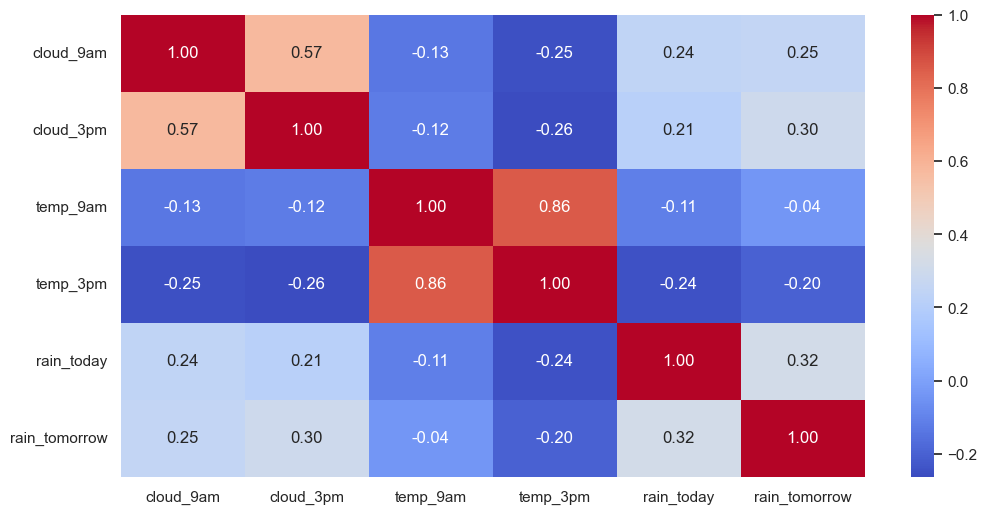

In [72]:
sns.heatmap(temp_clound.corr(), annot=True, cmap='coolwarm', fmt='.2f', cbar=True)